# Labour market (gmina wages and employment)

Explore the harmonised labour-market tables under `data/processed/labour_market`:

- **`labor_tidy_<year>.csv`** — gmina-level workplace / residence wages and employment for **2011**, **2021**, and the recent **~2026** window (2021 TERYT frame, 2\,477 gminas)
- **`teryt_gmina_crosswalk_2021.csv`** — vintage → 2021 code map used by the build pipeline
- **`labor_build_diagnostics.json`** — transfer-model coefficients and validation flags

Geometry comes from `data/processed/shapefiles/communes_2021.gpkg` (join on 7-digit TERYT). Maps are displayed only (not written to disk). Before committing, clear outputs:

```bash
python scripts/strip_notebook_outputs.py notebooks/05_labour_market.ipynb
```


In [10]:
# --- config ---
YEARS = (2011, 2021, 2026)  # tidy cross-sections to load
MAP_YEAR = 2026             # primary choropleth year
GROWTH_BASE, GROWTH_END = 2011, 2026
COMMUNES_GPKG = "communes_2021.gpkg"
PLOT_COUNTIES = False


In [11]:
from pathlib import Path
import json
import shutil
import subprocess

import ipynbname
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib.colors import LogNorm, TwoSlopeNorm

try:
    REPO_ROOT = Path(ipynbname.path()).parent.parent
except Exception:
    # nbconvert / non-interactive kernels: fall back to cwd
    _cwd = Path.cwd().resolve()
    REPO_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_ROOT = REPO_ROOT / "data"
LABOR_DIR = DATA_ROOT / "processed" / "labour_market"
COMMUNES_PATH = DATA_ROOT / "processed" / "shapefiles" / COMMUNES_GPKG


def _kpsewhich(name: str) -> str:
    if not shutil.which("kpsewhich"):
        return ""
    return subprocess.run(
        ["kpsewhich", name], capture_output=True, text=True
    ).stdout.strip()


if not _kpsewhich("type1cm.sty"):
    shim_dir = Path.home() / "texmf" / "tex" / "latex" / "type1cm"
    shim_dir.mkdir(parents=True, exist_ok=True)
    (shim_dir / "type1cm.sty").write_text(
        "% Shim for matplotlib usetex: map type1cm -> cm-super type1ec.\n"
        "\\ProvidesPackage{type1cm}\n"
        "\\RequirePackage{type1ec}\n"
    )

_latex_preamble = r"\usepackage[T1]{fontenc}\usepackage{amsmath}\usepackage{amssymb}"
if _kpsewhich("siunitx.sty"):
    _latex_preamble += r"\usepackage{siunitx}[=v2]"

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 16.0,
    "font.family": "serif",
    "font.serif": "Palatino",
    "axes.titlesize": "medium",
    "figure.titlesize": "large",
    "legend.fontsize": "medium",
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.autolayout": True,
    "text.usetex": True,
    "text.latex.preamble": _latex_preamble,
})

_PL_LATEX = {
    "ą": r"\k{a}", "ć": r"\'c", "ę": r"\k{e}", "ł": r"\l{}",
    "ń": r"\'n", "ó": r"\'o", "ś": r"\'s", "ź": r"\'z", "ż": r"\.{z}",
    "Ą": r"\k{A}", "Ć": r"\'C", "Ę": r"\k{E}", "Ł": r"\L{}",
    "Ń": r"\'N", "Ó": r"\'O", "Ś": r"\'S", "Ź": r"\'Z", "Ż": r"\.{Z}",
}


def _fix_utf8_mojibake(s: str) -> str:
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def latex_text(s: str) -> str:
    s = _fix_utf8_mojibake(str(s))
    for ch, rep in _PL_LATEX.items():
        s = s.replace(ch, rep)
    return s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")


def load_labor(year: int) -> pd.DataFrame:
    path = LABOR_DIR / f"labor_tidy_{year}.csv"
    df = pd.read_csv(path)
    df["year"] = int(year)
    df["JPT_KOD_JE"] = df["teryt7"].astype(str).str.zfill(7)
    return df


In [12]:
communes = gpd.read_file(COMMUNES_PATH, layer="communes")
communes["JPT_KOD_JE"] = communes["JPT_KOD_JE"].astype(str).str.zfill(7)
communes["JPT_NAZWA_"] = communes["JPT_NAZWA_"].map(_fix_utf8_mojibake)

counties = gpd.read_file(DATA_ROOT / "raw" / "shapefiles" / "PRG_jednostki_administracyjne_2021" / "A02_Granice_powiatow.shp")
counties = counties.to_crs(communes.crs)

labor = pd.concat([load_labor(y) for y in YEARS], ignore_index=True)
labor_wide = {y: labor.loc[labor["year"] == y].copy() for y in YEARS}

diag = json.loads((LABOR_DIR / "labor_build_diagnostics.json").read_text())
crosswalk = pd.read_csv(LABOR_DIR / "teryt_gmina_crosswalk_2021.csv")

# Attach primary-year labour columns to geometry
gdf = communes.merge(labor_wide[MAP_YEAR], on="JPT_KOD_JE", how="left", suffixes=("", "_lab"))
gdf["emp_ratio"] = gdf["employment_workplace"] / gdf["employment_residence"]
gdf["wage_gap"] = (
    gdf["median_income_residence"] - gdf["median_income_workplace"]
)

# Growth: workplace wage end vs base
base = labor_wide[GROWTH_BASE][["JPT_KOD_JE", "median_income_workplace"]].rename(
    columns={"median_income_workplace": "wage_base"}
)
end = labor_wide[GROWTH_END][["JPT_KOD_JE", "median_income_workplace"]].rename(
    columns={"median_income_workplace": "wage_end"}
)
growth = base.merge(end, on="JPT_KOD_JE")
growth["wage_growth"] = growth["wage_end"] / growth["wage_base"] - 1.0
gdf = gdf.merge(growth[["JPT_KOD_JE", "wage_growth"]], on="JPT_KOD_JE", how="left")

print(
    f"{len(communes)} communes  |  CRS={communes.crs}  |  "
    f"labour rows={len(labor):,} across {list(YEARS)}"
)
print(
    f"MAP_YEAR={MAP_YEAR}: wage workplace "
    f"[{gdf['median_income_workplace'].min():.0f}, "
    f"{gdf['median_income_workplace'].max():.0f}] zł  |  "
    f"emp workplace sum={gdf['employment_workplace'].sum():,.0f}"
)
print(
    f"diagnostics all_passed={diag.get('validation', {}).get('all_passed')}  |  "
    f"crosswalk rows={len(crosswalk):,}"
)


2477 communes  |  CRS=EPSG:3035  |  labour rows=7,431 across [2011, 2021, 2026]
MAP_YEAR=2026: wage workplace [5695, 13100] zł  |  emp workplace sum=15,125,030
diagnostics all_passed=True  |  crosswalk rows=7,435


## 1. Workplace median wage

Gmina mean workplace income (`median_income_workplace`) for `MAP_YEAR`. Recent-window values come from GUS P4609; 2011/2021 are powiat-benchmarked disaggregations (see methodology note in `scripts/labour_market/wages/`).


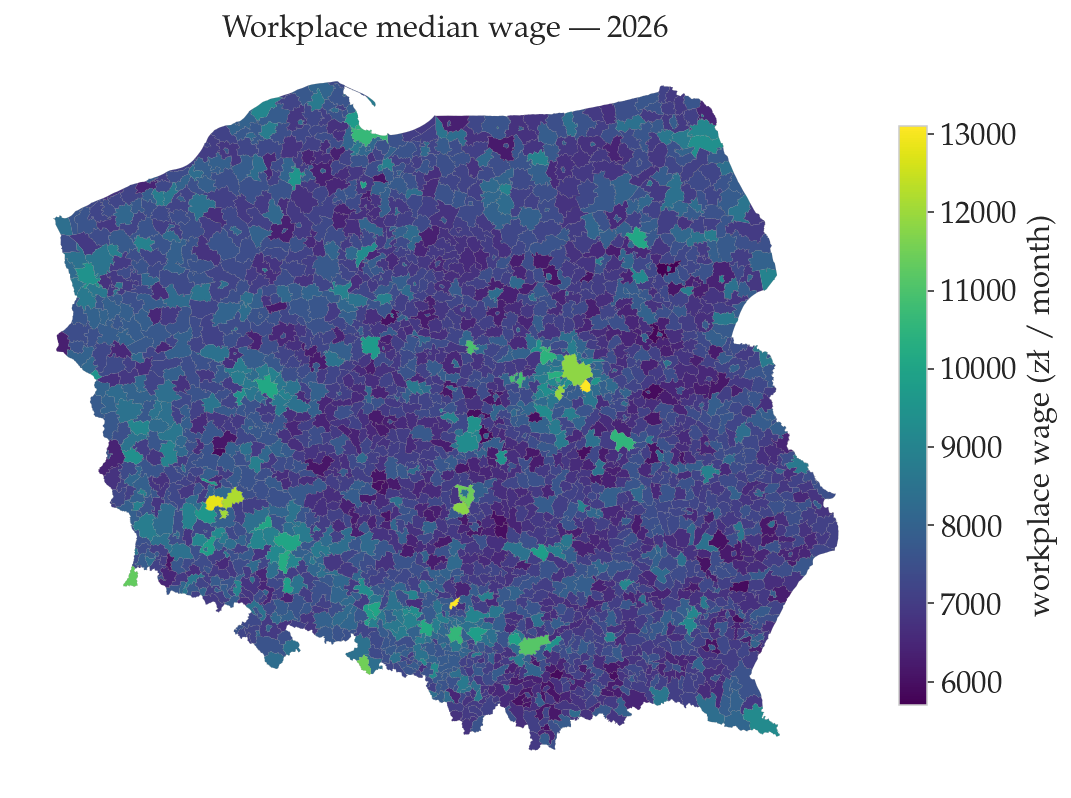

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.set_dpi(140)

gdf.plot(
    ax=ax,
    column="median_income_workplace",
    cmap="viridis",
    edgecolor="0.35",
    linewidth=0.05,
    legend=True,
    legend_kwds={
        "label": r"workplace wage (z\l{} / month)",
        "shrink": 0.55,
        "pad": 0.02,
    },
    missing_kwds={"color": "0.85"},
)

if PLOT_COUNTIES:
    counties.plot(
        ax=ax,
        color="none",
        edgecolor="black",
        linewidth=0.2,
    )

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(rf"Workplace median wage --- {MAP_YEAR}")
plt.show()


## 2. Workplace employment

Place-of-work employment counts on a log colour scale (large cities dominate the linear scale).


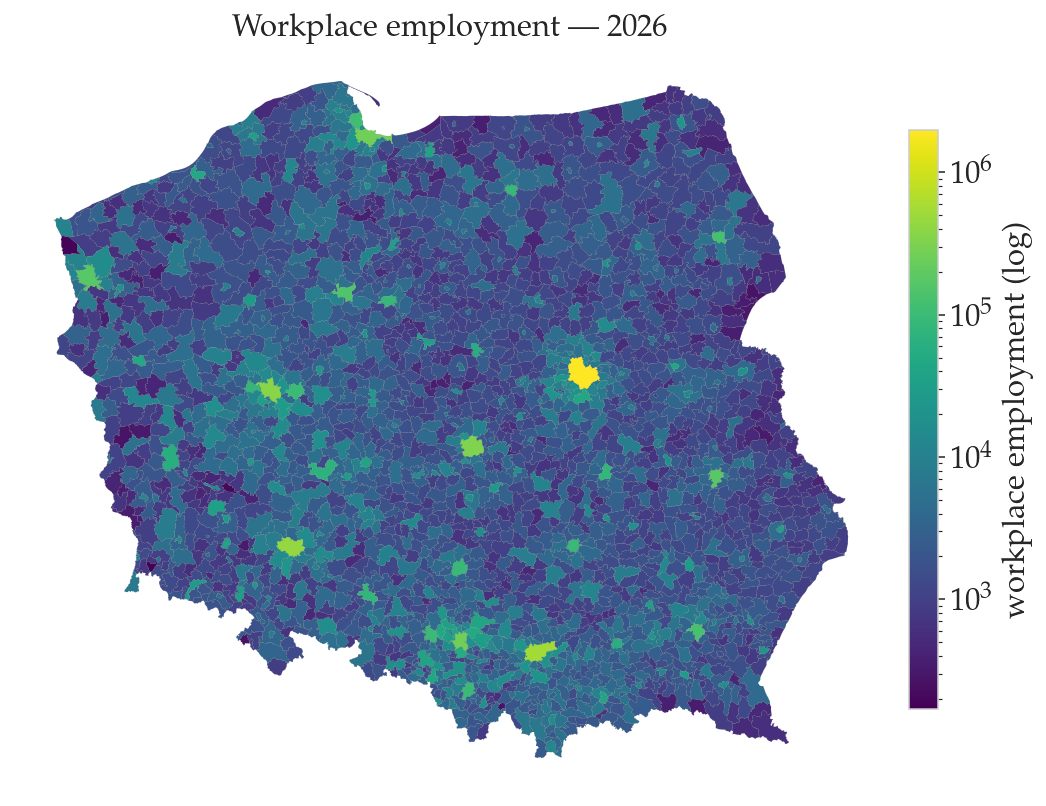

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.set_dpi(140)

emp = gdf["employment_workplace"].to_numpy(dtype=float)
norm = LogNorm(vmin=max(float(np.nanmin(emp)), 1.0), vmax=float(np.nanmax(emp)))

gdf.plot(
    ax=ax,
    column="employment_workplace",
    cmap="viridis",
    norm=norm,
    edgecolor="0.35",
    linewidth=0.05,
    legend=True,
    legend_kwds={
        "label": r"workplace employment (log)",
        "shrink": 0.55,
        "pad": 0.02,
    },
    missing_kwds={"color": "0.85"},
)

if PLOT_COUNTIES:
    counties.plot(
        ax=ax,
        color="none",
        edgecolor="black",
        linewidth=0.2,
    )
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(rf"Workplace employment --- {MAP_YEAR}")
plt.show()

## 3. Jobs vs residents (net commuting)

Ratio of workplace to residence employment, $L_n / R_n$. Values $>1$ mark job centres (in-commuting); $<1$ mark bedroom gminas.


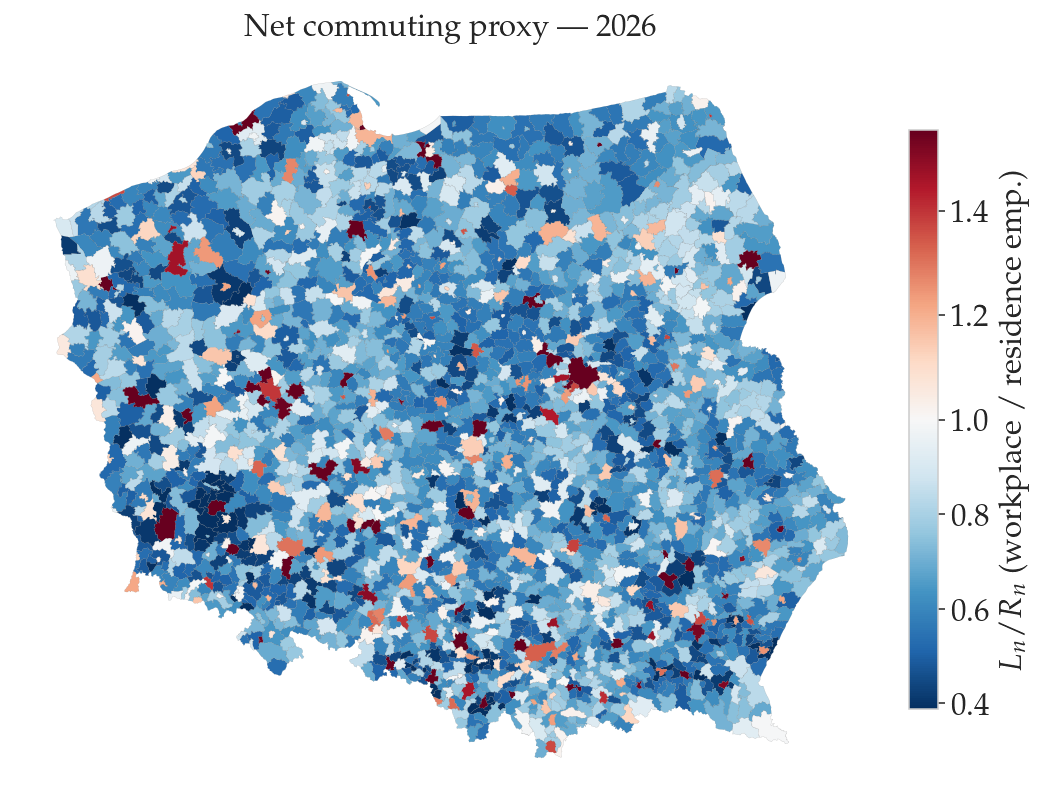

emp_ratio median=0.667  |  share L>R: 11.3%  |  colour scale [0.39, 1.56] (2--98 pct)


In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.set_dpi(140)

ratio = gdf["emp_ratio"].to_numpy(dtype=float)
finite = ratio[np.isfinite(ratio)]
# Winsorise colour scale at 2nd/98th pct so city outliers do not flatten the map
lo, hi = np.nanpercentile(finite, [2, 98])
lo = min(lo, 1.0 - 1e-6)
hi = max(hi, 1.0 + 1e-6)
norm = TwoSlopeNorm(vmin=lo, vcenter=1.0, vmax=hi)

gdf.plot(
    ax=ax,
    column="emp_ratio",
    cmap="RdBu_r",
    norm=norm,
    edgecolor="0.35",
    linewidth=0.05,
    legend=True,
    legend_kwds={
        "label": r"$L_n / R_n$ (workplace / residence emp.)",
        "shrink": 0.55,
        "pad": 0.02,
    },
    missing_kwds={"color": "0.85"},
)

if PLOT_COUNTIES:
    counties.plot(
        ax=ax,
        color="none",
        edgecolor="black",
        linewidth=0.2,
    )
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(rf"Net commuting proxy --- {MAP_YEAR}")
plt.show()
print(
    f"emp_ratio median={np.nanmedian(finite):.3f}  |  "
    f"share L>R: {(finite > 1).mean():.1%}  |  "
    f"colour scale [{lo:.2f}, {hi:.2f}] (2--98 pct)"
)


## 4. Workplace wage growth (base $\to$ end)

Relative change in workplace median wage between `GROWTH_BASE` and `GROWTH_END`:
$(w^{\mathrm{end}} / w^{\mathrm{base}}) - 1$.


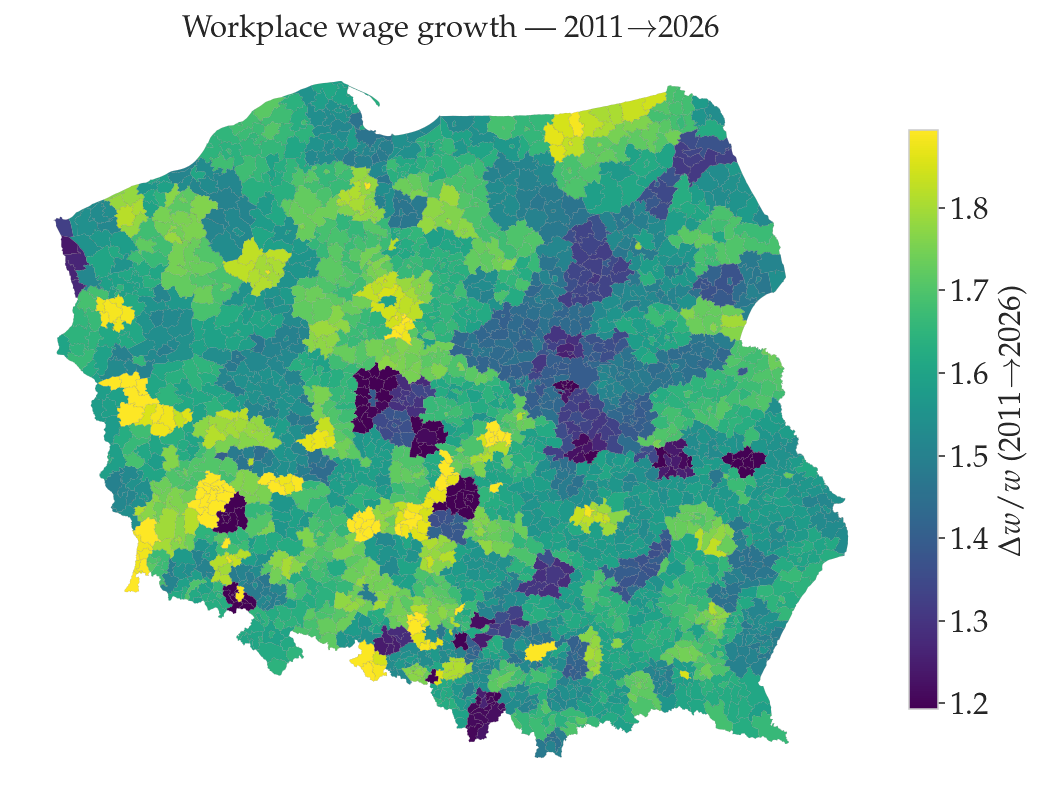

growth median=160.2%  |  mean=159.3%  |  colour scale [119.3%, 189.4%] (2--98 pct)


In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.set_dpi(140)

g = gdf["wage_growth"].to_numpy(dtype=float)
finite = g[np.isfinite(g)]
lo, hi = np.nanpercentile(finite, [2, 98])
norm = plt.Normalize(vmin=lo, vmax=hi)

gdf.plot(
    ax=ax,
    column="wage_growth",
    cmap="viridis",
    norm=norm,
    edgecolor="0.35",
    linewidth=0.05,
    legend=True,
    legend_kwds={
        "label": rf"$\Delta w / w$ ({GROWTH_BASE}$\to${GROWTH_END})",
        "shrink": 0.55,
        "pad": 0.02,
    },
    missing_kwds={"color": "0.85"},
)

if PLOT_COUNTIES:
    counties.plot(
        ax=ax,
        color="none",
        edgecolor="black",
        linewidth=0.2,
    )
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(
    rf"Workplace wage growth --- {GROWTH_BASE}$\to${GROWTH_END}"
)
plt.show()

print(
    f"growth median={np.nanmedian(finite):.1%}  |  "
    f"mean={np.nanmean(finite):.1%}  |  "
    f"colour scale [{lo:.1%}, {hi:.1%}] (2--98 pct)"
)


## 5. Cross-section distributions

Workplace wages across years, and by gmina type (`rodz_class`) in `MAP_YEAR`. Residence wages are only observed in the recent window.


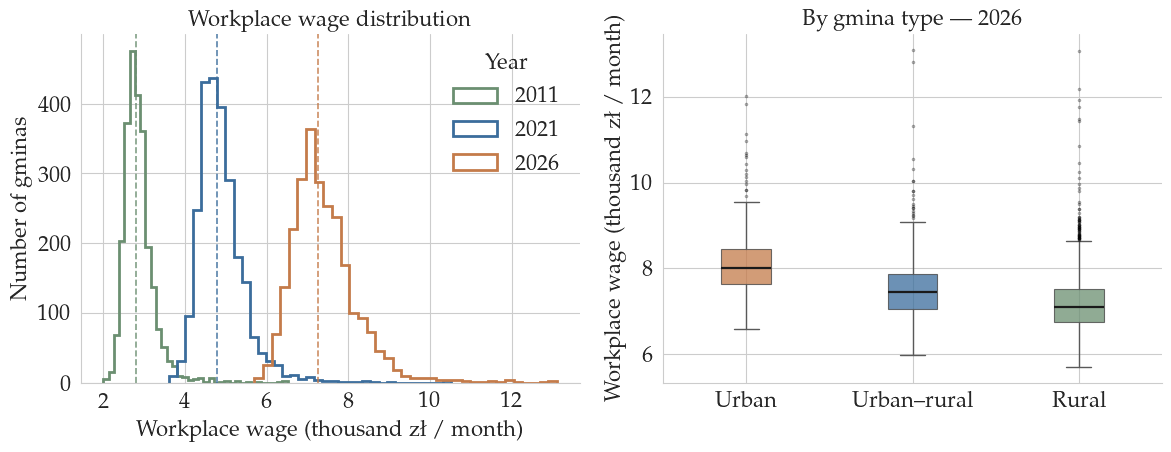

      wage_work_med  wage_res_med  emp_work_sum  emp_res_sum     n
year                                                              
2011         2804.1           NaN     8670325.0    8670915.0  2477
2021         4785.6           NaN     9826509.0    9838085.0  2477
2026         7261.7        7766.4    15125030.0   15048443.7  2477


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# --- left: wage histograms by year ---
ax = axes[0]
colors = {2011: "#6B8F71", 2021: "#3B6D9C", 2026: "#C47B4A"}
for y in YEARS:
    vals = labor_wide[y]["median_income_workplace"].dropna() / 1e3
    ax.hist(
        vals,
        bins=35,
        histtype="step",
        linewidth=2.0,
        color=colors.get(y, "0.4"),
        label=rf"{y}",
    )
    ax.axvline(
        vals.median(),
        color=colors.get(y, "0.4"),
        lw=1.2,
        ls="--",
        alpha=0.85,
    )
ax.set_xlabel(r"Workplace wage (thousand z\l{} / month)")
ax.set_ylabel(r"Number of gminas")
ax.set_title(r"Workplace wage distribution")
ax.legend(frameon=False, title=r"Year")
sns.despine(ax=ax)

# --- right: box by rodz_class ---
ax = axes[1]
order = ["urban", "urban_rural", "rural"]
labels = {
    "urban": r"Urban",
    "urban_rural": r"Urban--rural",
    "rural": r"Rural",
}
plot_df = labor_wide[MAP_YEAR].copy()
plot_df["wage_k"] = plot_df["median_income_workplace"] / 1e3
data = [plot_df.loc[plot_df["rodz_class"] == k, "wage_k"].dropna() for k in order]
bp = ax.boxplot(
    data,
    tick_labels=[labels[k] for k in order],
    patch_artist=True,
    medianprops={"color": "0.1", "linewidth": 1.6},
    whiskerprops={"color": "0.35"},
    capprops={"color": "0.35"},
    boxprops={"edgecolor": "0.25", "linewidth": 0.8},
    flierprops={"marker": ".", "markersize": 3, "alpha": 0.35},
)
palette = ["#C47B4A", "#3B6D9C", "#6B8F71"]
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_ylabel(r"Workplace wage (thousand z\l{} / month)")
ax.set_title(rf"By gmina type --- {MAP_YEAR}")
sns.despine(ax=ax)

plt.show()

summary = (
    labor.groupby("year")
    .agg(
        wage_work_med=("median_income_workplace", "median"),
        wage_res_med=("median_income_residence", "median"),
        emp_work_sum=("employment_workplace", "sum"),
        emp_res_sum=("employment_residence", "sum"),
        n=("region_id", "size"),
    )
    .round(1)
)
print(summary.to_string())


## 6. Residence vs workplace wage (recent window)

For `MAP_YEAR` only: residence wage minus workplace wage. Positive values mean residents earn more than local jobs pay (typical of suburban out-commuting gminas).


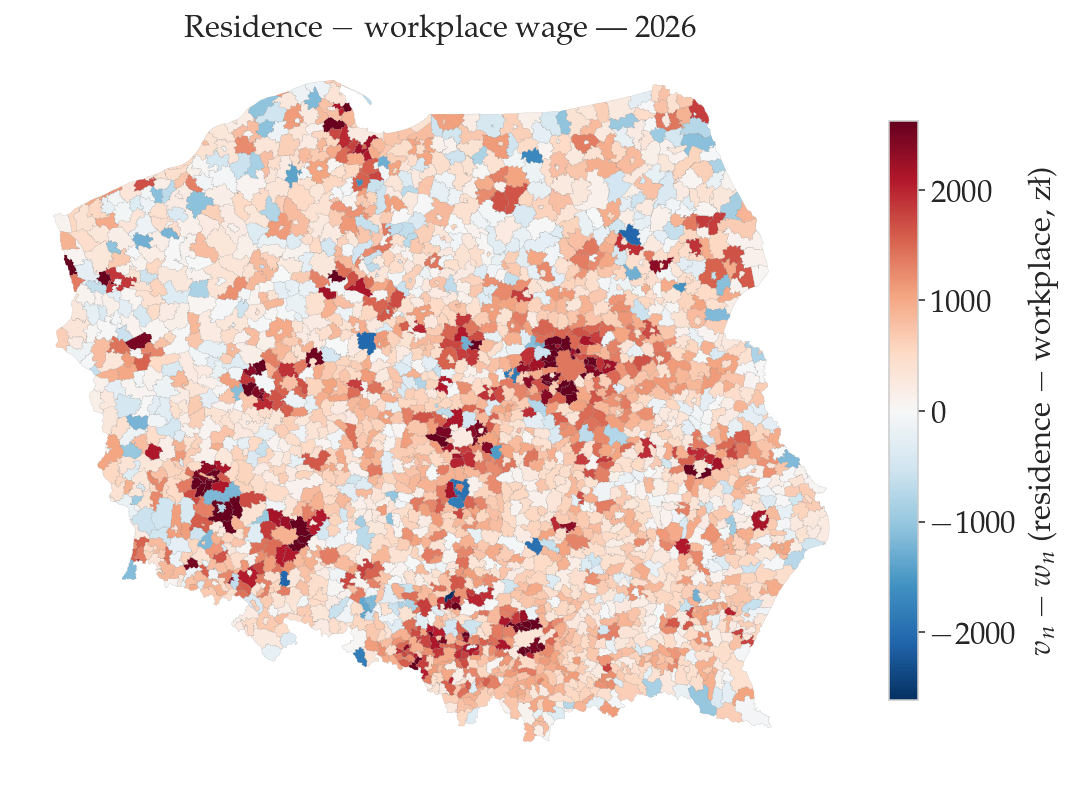

wage gap median=+521 zł  |  mean=+603 zł  |  share v>w: 82.3%


In [18]:
if gdf["median_income_residence"].notna().sum() == 0:
    print(f"No residence wages in MAP_YEAR={MAP_YEAR}; skip gap map.")
else:
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.set_dpi(140)

    gap = gdf["wage_gap"].to_numpy(dtype=float)
    finite = gap[np.isfinite(gap)]
    lim = float(np.nanpercentile(np.abs(finite), 98))
    lim = max(lim, 1.0)
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    gdf.plot(
        ax=ax,
        column="wage_gap",
        cmap="RdBu_r",
        norm=norm,
        edgecolor="0.35",
        linewidth=0.05,
        legend=True,
        legend_kwds={
            "label": r"$v_n - w_n$ (residence $-$ workplace, z\l{})",
            "shrink": 0.55,
            "pad": 0.02,
        },
        missing_kwds={"color": "0.85"},
    )
    if PLOT_COUNTIES:
        counties.plot(
            ax=ax,
            color="none",
            edgecolor="black",
            linewidth=0.2,
        )
    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.set_title(rf"Residence $-$ workplace wage --- {MAP_YEAR}")
    plt.show()

    print(
        f"wage gap median={np.nanmedian(finite):+.0f} zł  |  "
        f"mean={np.nanmean(finite):+.0f} zł  |  "
        f"share v>w: {(finite > 0).mean():.1%}"
    )
